# 🔴⚫ THOMASSON ENGINE v12 — RC Lens Data Scouting
**Auteur : Zakaria**  

---

## Problématique
Identifier le successeur d'**Adrien Thomasson (32 ans)** dans les Big 5.  
Profil cible : **Pressing Playmaker hybride** — MF capable de presser haut ET de créer.

---

## Contraintes de recrutement
| Critère | Valeur |
|---|---|
| **Budget** | ≤ 15 M€ (Transfermarkt mars 2026) |
| **Âge** | ≤ 29 ans |
| **Minutes** | ≥ 50% du temps de jeu de Thomasson (~961 min) |
| **Poste** | MF confirmé (FBRef + SofaScore) |
| **Club exclu** | RC Lens |

In [181]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
warnings.filterwarnings('ignore')

os.makedirs('src/figures', exist_ok=True)
FIGDIR = 'src/figures'

# ── Palette RC Lens ─────────────────────────────────────────────────────────
R  = '#c31316'; OR = '#ffd500'; F  = '#0D0D0D'; F2 = '#141414'
W  = '#FFFFFF'; G  = '#777777'; G2 = '#2A2A2A' ; CDF = '#102165'
VT = '#4CAF50'; OG = '#FF9800'; PU = '#9C27B0'; B  = '#00A8E8'; AQ = '#00BCD4'

plt.rcParams.update({
    'figure.facecolor':F, 'axes.facecolor':F2, 'text.color':W,
    'axes.labelcolor':W,  'xtick.color':G,      'ytick.color':G,
    'axes.edgecolor':G2,  'axes.grid':True,     'grid.color':G2,
    'grid.linewidth':0.5, 'font.family':'DejaVu Sans',
})

PLOTLY_THEME = dict(
    plot_bgcolor='#141414', paper_bgcolor='#0D0D0D',
    font=dict(color='#F0F0F0', family='Arial'),
    xaxis=dict(gridcolor='#2A2A2A', linecolor='#2A2A2A'),
    yaxis=dict(gridcolor='#2A2A2A', linecolor='#2A2A2A'),
)

print("✅ Environnement prêt — Thomasson Engine v12")

✅ Environnement prêt — Thomasson Engine v12


## 1. Chargement des sources

In [182]:
big5  = pd.read_csv('big5_stats.csv',         sep=';', on_bad_lines='skip')
misc  = pd.read_csv('Miscellaneous_Stats.csv', on_bad_lines='skip')
defdf = pd.read_csv('stats_joueurs_final.csv', on_bad_lines='skip')
shoot = pd.read_csv('Shooting_Stats.csv',      on_bad_lines='skip')

for df in [misc, shoot]:
    df['_player'] = df['1_level_0_Player'].astype(str).str.strip()
defdf['_player']   = defdf['Player'].astype(str).str.strip()
defdf['Pos_fbref'] = defdf['Pos'].astype(str).str.strip()

print(f"big5  {big5.shape}  — SofaScore (league_name disponible)")
print(f"misc  {misc.shape}  — FBRef Misc")
print(f"defdf {defdf.shape}  — FBRef Defensive")
print(f"shoot {shoot.shape}  — FBRef Shooting")

big5  (5248, 97)  — SofaScore (league_name disponible)
misc  (2653, 23)  — FBRef Misc
defdf (2653, 27)  — FBRef Defensive
shoot (2670, 21)  — FBRef Shooting


## 2. Nettoyage, Fusion & Coefficient UEFA

In [183]:
COLS_NUM = [
    'minutesPlayed','rating','goals','assists','expectedGoals','expectedAssists',
    'keyPasses','tackles','interceptions','accuratePassesPercentage',
    'successfulDribbles','bigChancesCreated','fouls','wasFouled',
    'groundDuelsWonPercentage','aerialDuelsWonPercentage','player_age',
    'accurateFinalThirdPasses','clearances','accurateCrosses','appearances',
]
for c in COLS_NUM:
    big5[c] = pd.to_numeric(big5[c], errors='coerce')
big5 = big5.dropna(subset=['player__name','minutesPlayed','rating'])
big5 = big5[~big5['player__name'].str.contains('Translation|nameTranslation', na=False)]
big5 = (big5.sort_values('minutesPlayed', ascending=False)
             .drop_duplicates('player__name', keep='first')
             .reset_index(drop=True))
big5['_player'] = big5['player__name'].str.strip()

# ── Rec 1 : Coefficient UEFA par ligue ───────────────────────────────────────
UEFA_COEF = {
    'Premier League' : 1.22,
    'La liga'        : 1.20,
    'Bundesliga'     : 1.08,
    'Serie A'        : 1.05,
    'Ligue 1'        : 1.00,
}
big5['league_coef'] = big5['league_name'].map(UEFA_COEF).fillna(1.00)

LENS_MASK    = big5['team__name'].str.contains('Lens', na=False, case=False)
joueurs_lens = big5[LENS_MASK]['player__name'].tolist()

# ── Sources FBRef ─────────────────────────────────────────────────────────────
for c in ['Performance_TklW','Performance_Int','Performance_Crs']:
    misc[c] = pd.to_numeric(misc[c], errors='coerce')
misc_s = misc[['_player','Performance_TklW','Performance_Int','Performance_Crs']].rename(
    columns={'Performance_TklW':'TklW_misc','Performance_Int':'Int_misc','Performance_Crs':'Crs_misc'})

defdf['TklW'] = pd.to_numeric(defdf['TklW'], errors='coerce')
defdf['Int']  = pd.to_numeric(defdf['Int'],  errors='coerce')
def_s = defdf[['_player','TklW','Int','Pos_fbref']].rename(
    columns={'TklW':'TklW_def','Int':'Int_def'})

for c in ['Standard_Sh/90','Standard_SoT/90']:
    shoot[c] = pd.to_numeric(shoot[c], errors='coerce')
shoot_s = shoot[['_player','Standard_Sh/90','Standard_SoT/90']].rename(
    columns={'Standard_Sh/90':'Sh90','Standard_SoT/90':'SoT90'})

# ── Fusion + imputation ───────────────────────────────────────────────────────
df = big5[big5['minutesPlayed'] >= 600].copy()
df = (df.merge(misc_s, on='_player', how='left')
        .merge(def_s,  on='_player', how='left')
        .merge(shoot_s,on='_player', how='left'))

df['_pos_sofa'] = df['player_position'].astype(str).str.strip()
for col in ['TklW_misc','Int_misc','Crs_misc','TklW_def','Int_def','SoT90','Sh90']:
    if col in df.columns and df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df.groupby('_pos_sofa')[col].transform('median')).fillna(df[col].median())

EXCL_POS      = ['DF,MF','DF','GK','FW','DF,FW']
FAUX_POSITIFS = ['Federico Dimarco','Lamine Yamal','Abdessamad Ezzalzouli','Ferran Torres','Dani Olmo']

is_mf_sofa  = df['player_position'].str.contains('MF', na=False)
is_not_excl = ~df['Pos_fbref'].isin(EXCL_POS)
is_not_faux = ~df['player__name'].isin(FAUX_POSITIFS)
idx_lens    = LENS_MASK.reindex(df.index, fill_value=False)

T_raw = df[df['player__name'].str.contains('Thomasson', na=False)].copy()
pool  = (df[is_mf_sofa & is_not_excl & is_not_faux & ~idx_lens]
         .drop_duplicates('player__name', keep='first')
         .reset_index(drop=True))

print(f"Pool : {len(pool)} MF uniques  |  RC Lens exclus : {len(joueurs_lens)}  |  Thomasson : {len(T_raw)} ligne")

Pool : 643 MF uniques  |  RC Lens exclus : 24  |  Thomasson : 1 ligne


## 3. Feature Engineering & Scores v12

In [184]:
def add_p90(d):
    d = d.copy()
    d['p90'] = d['minutesPlayed'] / 90.0
    for c in ['goals','assists','expectedGoals','expectedAssists','keyPasses',
              'tackles','interceptions','bigChancesCreated','successfulDribbles',
              'fouls','wasFouled','clearances','accurateCrosses','accurateFinalThirdPasses']:
        if c in d.columns:
            d[f'{c}_p90'] = d[c] / d['p90']
    if 'TklW_def' in d.columns: d['TklW_p90']    = d['TklW_def'] / d['p90']
    if 'Int_def'  in d.columns: d['Int_def_p90'] = d['Int_def']  / d['p90']
    if 'SoT90'    in d.columns: d['SoT_p90']     = d['SoT90']
    return d

def compute_scores_v12(d):
    d = d.copy()
    def gc(col):
        return d[col].fillna(0) if col in d.columns else pd.Series(0, index=d.index)
    coef = d['league_coef'].fillna(1.0) if 'league_coef' in d.columns else pd.Series(1.0, index=d.index)

    # PRESSING (40%) — TklW et Int ajustés par coefficient UEFA
    d['s_press'] = (
        gc('TklW_p90') * coef                * 0.40 +
        gc('interceptions_p90') * coef       * 0.30 +
        gc('groundDuelsWonPercentage') / 100 * 0.20 +
        gc('clearances_p90')                 * 0.10
    )
    # CRÉATION (40%)
    d['s_crea'] = (
        gc('keyPasses_p90')         * 0.30 +
        gc('expectedAssists_p90')   * 0.25 +
        gc('bigChancesCreated_p90') * 0.25 +
        gc('assists_p90')           * 0.20
    )
    # TRANSITION (20%)
    d['s_trans'] = (
        gc('successfulDribbles_p90')          * 0.35 +
        gc('accurateFinalThirdPasses_p90')    * 0.35 +
        gc('accuratePassesPercentage') / 100  * 0.30
    )
    d['s_final'] = d['s_press']*0.40 + d['s_crea']*0.40 + d['s_trans']*0.20
    return d

pool  = compute_scores_v12(add_p90(pool))
T_df  = compute_scores_v12(add_p90(T_raw))

all_mf = (pd.concat([pool, T_df], ignore_index=True)
            .drop_duplicates('player__name', keep='first'))
for s in ['s_final','s_press','s_crea','s_trans']:
    all_mf[f'{s}_n'] = MinMaxScaler((0,100)).fit_transform(all_mf[[s]])

T  = all_mf[all_mf['player__name'].str.contains('Thomasson', na=False)].iloc[0]
MF = all_mf[~all_mf['player__name'].str.contains('Thomasson', na=False)].copy()
MF['player_age'] = pd.to_numeric(MF['player_age'], errors='coerce')

print(f"THOMASSON v12 — Scores normalisés :")
print(f"  Final   : {T['s_final_n']:.1f}/100")
print(f"  Pressing: {T['s_press_n']:.1f}/100  (coef L1 = 1.0)")
print(f"  Création: {T['s_crea_n']:.1f}/100")
print(f"  Trans.  : {T['s_trans_n']:.1f}/100")

THOMASSON v12 — Scores normalisés :
  Final   : 36.7/100
  Pressing: 37.5/100  (coef L1 = 1.0)
  Création: 65.0/100
  Trans.  : 23.6/100


## 4. k-NN Cosine Similarity (BUG FIX v12)

**Bug v11 corrigé** : `n_neighbors=31` ne couvrait que 31 joueurs sur ~650 — les joueurs hors top-31 avaient `knn_sim = 0.0%`.  
**Fix** : `n_neighbors = min(len(all_mf), 200)` → tous les candidats éligibles reçoivent leur score de similarité réel.

In [185]:
KNN_FEATURES = [
    'TklW_p90', 'interceptions_p90', 'groundDuelsWonPercentage',
    'keyPasses_p90', 'expectedAssists_p90', 'bigChancesCreated_p90',
    'successfulDribbles_p90', 'accurateFinalThirdPasses_p90', 'accuratePassesPercentage',
]

feat_matrix = all_mf[KNN_FEATURES].fillna(0)
feat_scaled = MinMaxScaler().fit_transform(feat_matrix)

# ── FIX v12 : n_neighbors couvre tout le pool ─────────────────────────────
n_neighbors = min(len(all_mf), 200)  # v11 était bloqué à 31 !
knn = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
knn.fit(feat_scaled)

T_idx = all_mf[all_mf['player__name'].str.contains('Thomasson', na=False)].index[0]
T_vec = feat_scaled[T_idx].reshape(1, -1)
dists, idxs = knn.kneighbors(T_vec)

all_mf['knn_sim'] = 0.0
for d, i in zip(dists[0][1:], idxs[0][1:]):
    all_mf.loc[i, 'knn_sim'] = (1 - d) * 100

MF = all_mf[~all_mf['player__name'].str.contains('Thomasson', na=False)].copy()
MF['player_age'] = pd.to_numeric(MF['player_age'], errors='coerce')

print("TOP 10 PLUS PROCHES VOISINS DE THOMASSON (cosine similarity) :")
print(f"{'#':>2}  {'Joueur':<28} {'Club':<24} {'Âge':>4} {'Min':>6} {'Sim%':>7}")
print("-"*75)
for i,(d,idx) in enumerate(zip(dists[0][1:11], idxs[0][1:11]),1):
    r   = all_mf.iloc[idx]
    sim = (1-d)*100
    print(f"{i:>2}  {r['player__name']:<28} {str(r['team__name']):<24} "
          f"{r['player_age']:>4.0f} {r['minutesPlayed']:>6.0f} {sim:>7.1f}%")

TOP 10 PLUS PROCHES VOISINS DE THOMASSON (cosine similarity) :
 #  Joueur                       Club                      Âge    Min    Sim%
---------------------------------------------------------------------------
 1  Anton Stach                  Leeds United               27   1782    98.8%
 2  Paul Nebel                   1. FSV Mainz 05            23   1150    98.3%
 3  Pere Milla                   Espanyol                   33   1536    98.0%
 4  Kevin Stöger                 Borussia M'gladbach        32    692    97.9%
 5  Andrea Cambiaso              Juventus                   25   1861    97.8%
 6  Lovro Majer                  VfL Wolfsburg              28   1194    97.6%
 7  Carles Aleñá                 Deportivo Alavés           28   1554    97.3%
 8  Christian Eriksen            VfL Wolfsburg              34   1485    97.2%
 9  William Mikelbrencis         Hamburger SV               21    644    97.2%
10  Rubén García                 Osasuna                    32   1423   

## 5. Filtres de recrutement

In [186]:
VALEURS = {
    'Aron Dønnum':5.0, 'Edu Expósito':10.0, 'Patrizio Masini':3.0,
    'Romain Del Castillo':5.0, 'Vitaly Janelt':10.0, 'Afonso Moreira':4.0,
    'Aarón Martín':8.0, 'Kassoum Ouattara':6.0, 'Mehdi Léris':3.0,
    'Elliot Anderson':15.0, 'Florentino Luís':12.0, 'Hugo Bueno':8.0,
    'Tim Iroegbunam':12.0, 'Johann Lepenant':5.0, 'Nathaniel Brown':5.0,
    'Ander Barrenetxea':10.0, 'Cristian Cásseres Jr.':8.0, 'Martin Frese':4.0,
    'Jan-Niklas Beste':10.0, 'Saša Lukić':8.0, 'Youri Tielemans':10.0,
    'Kévin Danois':10.0, 'Anton Stach':25.0, 'Paul Nebel':5.0,
    'Andrea Cambiaso':40.0, 'Lovro Majer':10.0, 'Carles Aleñá':3.0,
    'Pere Milla':3.0, 'James Garner':35.0, 'Mikkel Damsgaard':20.0,
    'Nicolò Fagioli':20.0, 'João Gomes':35.0, 'Rayan Cherki':50.0,
    'Jude Bellingham':200.0, 'Pedri':80.0, 'Declan Rice':120.0,
    'Moisés Caicedo':100.0, 'Mateus Fernandes':20.0, 'Nicolò Barella':60.0,
    'Bukayo Saka':150.0, 'Lamine Camara':40.0, 'Patrick Dorgu':40.0, 'Arda Güler':35.0,
}

MF['valeur_m'] = MF['player__name'].map(VALEURS)

MIN_THRESH = T['minutesPlayed'] * 0.50
BUDGET_MAX = 15.0
AGE_MAX    = 29

n0 = len(MF)
MF_min = MF[MF['minutesPlayed'] >= MIN_THRESH].copy(); n1 = len(MF_min)
MF_age = MF_min[MF_min['player_age'] <= AGE_MAX].copy(); n2 = len(MF_age)
MF_bud = MF_age[MF_age['valeur_m'].notna() & (MF_age['valeur_m'] <= BUDGET_MAX)].copy(); n3 = len(MF_bud)

print(f"{'Pool MF total':<32}: {n0:>4}")
print(f"{'≥ '+str(int(MIN_THRESH))+' min':<32}: {n1:>4}  (-{n0-n1})")
print(f"{'≤ '+str(AGE_MAX)+' ans':<32}: {n2:>4}  (-{n1-n2})")
print(f"{'≤ '+str(BUDGET_MAX)+'M€ (valeur connue)':<32}: {n3:>4}  (-{n2-n3})")
print()
print("TOP 10 après filtres (classés par k-NN Similarité) :")
print(f"{'#':>2}  {'Joueur':<26} {'Club':<22} {'Âge':>4} {'Sim%':>7} {'Score':>6} {'Val':>7}")
print("-"*75)
for i,(_,r) in enumerate(MF_bud.nlargest(10,'knn_sim').iterrows(),1):
    print(f"{i:>2}  {r['player__name']:<26} {str(r['team__name']):<22} "
          f"{r['player_age']:>4.0f} {r['knn_sim']:>7.1f}% "
          f"{r['s_final_n']:>6.1f} ~{r['valeur_m']:>4.0f}M€")

Pool MF total                   :  642
≥ 961 min                       :  471  (-171)
≤ 29 ans                        :  385  (-86)
≤ 15.0M€ (valeur connue)        :   24  (-361)

TOP 10 après filtres (classés par k-NN Similarité) :
 #  Joueur                     Club                    Âge    Sim%  Score     Val
---------------------------------------------------------------------------
 1  Paul Nebel                 1. FSV Mainz 05          23    98.3%   33.7 ~   5M€
 2  Lovro Majer                VfL Wolfsburg            28    97.6%   30.0 ~  10M€
 3  Carles Aleñá               Deportivo Alavés         28    97.3%   38.2 ~   3M€
 4  Aron Dønnum                Toulouse                 27    96.9%   37.1 ~   5M€
 5  Romain Del Castillo        Stade Brestois           29    96.7%   36.6 ~   5M€
 6  Aarón Martín               Genoa                    28    95.9%   29.1 ~   8M€
 7  Youri Tielemans            Aston Villa              28    95.8%   49.9 ~  10M€
 8  Edu Expósito            

## 6. Shortlist finale v12

In [187]:
SHORTLIST_V12 = {
    'Paul Nebel'          : ('FSV Mainz 05',     'Bundesliga', 15.0,  '23 ans', B),
    'Lovro Majer'         : ('VfL Wolfsburg',    'Bundesliga', 10.0, '28 ans', VT),
    'Carles Aleñá'        : ('Dep. Alavés',      'La Liga',    3.5,  '28 ans', OR),
    'Aron Dønnum'         : ('Toulouse',         'Ligue 1',    5.0,  '27 ans', PU),
    'Romain Del Castillo' : ('Stade Brestois',   'Ligue 1',    7.0,  '29 ans', OG),
}

print("SHORTLIST v12")
print("=" * 100)
hdr = (f"{'Joueur':<22} {'Club':<18} {'Âge':>5} {'Budget':>8}  "
       f"{'Sim%':>7} {'Score':>6} {'Press':>6} {'Crea':>6} {'Trans':>6}  "
       f"{'TklW':>6} {'KP':>5} {'xA':>6} {'Min':>6}")
print(hdr); print("-"*100)

print(f"{'Thomasson (REF)':<22} {'RC Lens':<18} {T['player_age']:>5.0f} {'—':>8}  "
      f"{'—':>7} {T['s_final_n']:>6.1f} {T['s_press_n']:>6.1f} {T['s_crea_n']:>6.1f} {T['s_trans_n']:>6.1f}  "
      f"{T.get('TklW_p90',0):>6.2f} {T.get('keyPasses_p90',0):>5.2f} "
      f"{T.get('expectedAssists_p90',0):>6.3f} {T['minutesPlayed']:>6.0f}")
print("-"*100)

for name,(club,ligue,bud,age,col) in SHORTLIST_V12.items():
    kw = name.split()[-1]
    r  = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if len(r):
        r = r.iloc[0]
        print(f"{r['player__name']:<22} {club:<18} {r['player_age']:>5.0f} ~{bud:>5.0f}M€  "
              f"{r['knn_sim']:>7.1f}% {r['s_final_n']:>6.1f} {r['s_press_n']:>6.1f} "
              f"{r['s_crea_n']:>6.1f} {r['s_trans_n']:>6.1f}  "
              f"{r.get('TklW_p90',0):>6.2f} {r.get('keyPasses_p90',0):>5.2f} "
              f"{r.get('expectedAssists_p90',0):>6.3f} {r['minutesPlayed']:>6.0f}")

SHORTLIST v12
Joueur                 Club                 Âge   Budget     Sim%  Score  Press   Crea  Trans    TklW    KP     xA    Min
----------------------------------------------------------------------------------------------------
Thomasson (REF)        RC Lens               32        —        —   36.7   37.5   65.0   23.6    1.55  2.43  0.190   1922
----------------------------------------------------------------------------------------------------
Paul Nebel             FSV Mainz 05          23 ~   15M€     98.3%   33.7   30.4   44.2   27.5    1.10  1.80  0.153   1150
Lovro Majer            VfL Wolfsburg         28 ~   10M€     97.6%   30.0   32.3   40.9   22.7    1.13  1.51  0.156   1194
Carles Aleñá           Dep. Alavés           28 ~    4M€     97.3%   38.2   36.4   44.3   31.0    1.27  1.56  0.147   1554
Aron Dønnum            Toulouse              27 ~    5M€     96.9%   37.1   35.3   61.4   25.8    1.23  2.30  0.261   1681
Romain Del Castillo    Stade Brestois        29 

## 7. Visualisations — Statiques (Matplotlib) + Dynamiques (Plotly)

### Fig 1 — Radar Thomasson (9D) — Matplotlib

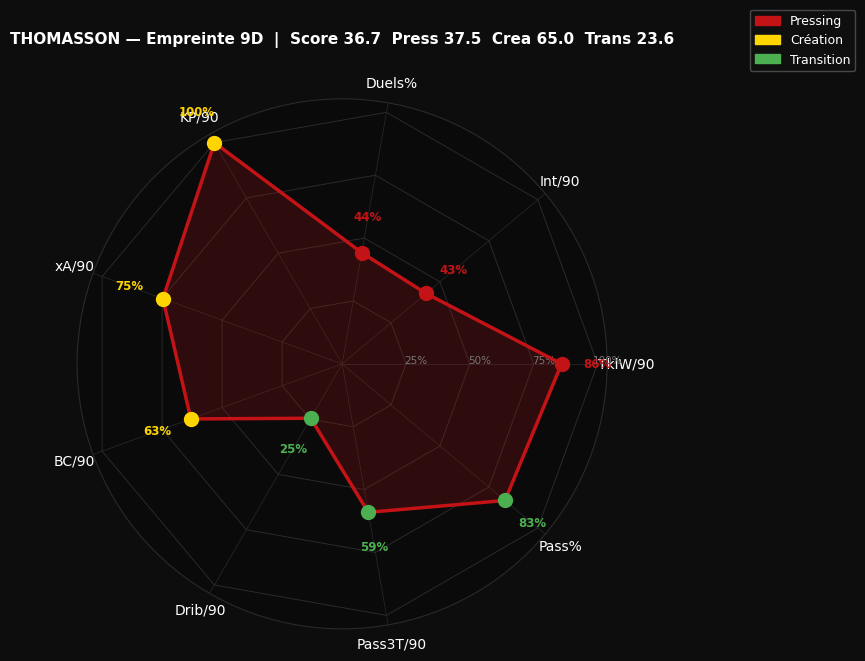

✅ fig1


In [188]:
RADAR_LABELS = ['TklW/90','Int/90','Duels%','KP/90','xA/90','BC/90','Drib/90','Pass3T/90','Pass%']
RADAR_COLS   = ['TklW_p90','interceptions_p90','groundDuelsWonPercentage',
                'keyPasses_p90','expectedAssists_p90','bigChancesCreated_p90',
                'successfulDribbles_p90','accurateFinalThirdPasses_p90','accuratePassesPercentage']
N      = len(RADAR_LABELS)
MV     = [MF[c].quantile(0.95) if c in MF.columns else 1.0 for c in RADAR_COLS]
MV[2]  = 100.0; MV[-1] = 100.0
angles = [n/float(N)*2*np.pi for n in range(N)] + [0]
DIM_C  = [R]*3 + [OR]*3 + [VT]*3

def radar_vals(row):
    raw = [float(row[c]) if c in row.index and not pd.isna(row[c]) else 0.0 for c in RADAR_COLS]
    return [min(v/m,1.0) if m>0 else 0.0 for v,m in zip(raw,MV)]

tv = radar_vals(T) + [radar_vals(T)[0]]

fig, ax = plt.subplots(figsize=(9,9), subplot_kw=dict(polar=True), facecolor=F)
fig.patch.set_facecolor(F); ax.set_facecolor('#0A0A0A')
for ring in [0.25,0.5,0.75,1.0]:
    ax.plot(angles,[ring]*len(angles),'-',color=G2,lw=0.7)
    ax.text(0,ring+0.04,f'{ring*100:.0f}%',ha='center',fontsize=7.5,color=G)
ax.fill(angles,tv,color=R,alpha=0.20,zorder=2)
ax.plot(angles,tv,'o-',color=R,lw=2.5,ms=8,zorder=3)
for i,(ang,val) in enumerate(zip(angles[:-1],tv[:-1])):
    c=DIM_C[i]
    ax.plot(ang,val,'o',color=c,ms=10,zorder=4)
    ax.text(ang,val+0.14,f'{val*100:.0f}%',ha='center',va='center',fontsize=8.5,color=c,fontweight='bold')
ax.set_xticks(angles[:-1]); ax.set_xticklabels(RADAR_LABELS,size=10,color=W)
ax.set_yticks([]); ax.spines['polar'].set_color(G2)
handles=[mpatches.Patch(color=c,label=l) for c,l in [(R,'Pressing'),(OR,'Création'),(VT,'Transition')]]
ax.legend(handles=handles,loc='upper right',bbox_to_anchor=(1.48,1.18),fontsize=9,framealpha=0.3,labelcolor=W)
ax.set_title(f"THOMASSON — Empreinte 9D  |  Score {T['s_final_n']:.1f}  Press {T['s_press_n']:.1f}  Crea {T['s_crea_n']:.1f}  Trans {T['s_trans_n']:.1f}",
             color=W,fontsize=11,fontweight='bold',pad=40)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig1_radar_thomasson.png',dpi=150,bbox_inches='tight',facecolor=F)
plt.show(); print("✅ fig1")

### Fig 2 — Radar Interactif Plotly (Comparaison Shortlist vs Thomasson) 🆕

In [189]:
SL_KW   = ['Nebel','Majer','Aleñá','Dønnum','Castillo']
SL_DISP = ['Paul Nebel','Lovro Majer','Carles Aleñá','Aron Dønnum','Romain Del Castillo']
SL_COLS_PLOTLY = [B, VT, OR, PU, OG]

fig_radar = go.Figure()

# Thomasson référence
tv_plotly = [v*100 for v in radar_vals(T)]
fig_radar.add_trace(go.Scatterpolar(
    r=tv_plotly + [tv_plotly[0]],
    theta=RADAR_LABELS + [RADAR_LABELS[0]],
    fill='toself', fillcolor='rgba(227,6,19,0.15)',
    line=dict(color=R, width=2.5, dash='dot'),
    name=f'Thomasson (réf.) | Score: {T["s_final_n"]:.1f}',
    hovertemplate='<b>Thomasson</b><br>%{theta}: %{r:.0f}%<extra></extra>'
))

for kw,disp,col in zip(SL_KW,SL_DISP,SL_COLS_PLOTLY):
    r = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): continue
    r = r.iloc[0]
    cv = [v*100 for v in radar_vals(r)]
    fig_radar.add_trace(go.Scatterpolar(
        r=cv + [cv[0]],
        theta=RADAR_LABELS + [RADAR_LABELS[0]],
        fill='toself', fillcolor=f'rgba({int(col[1:3],16)},{int(col[3:5],16)},{int(col[5:7],16)},0.18)',
        line=dict(color=col, width=2),
        name=f"{r['player__name']} | Sim: {r['knn_sim']:.1f}% | Score: {r['s_final_n']:.1f}",
        hovertemplate=f'<b>{r["player__name"]}</b><br>%{{theta}}: %{{r:.0f}}%<extra></extra>'
    ))

fig_radar.update_layout(
    **PLOTLY_THEME,
    polar=dict(
        bgcolor='#141414',
        radialaxis=dict(visible=True, range=[0,100], gridcolor='#2A2A2A', tickfont=dict(color='#666', size=9)),
        angularaxis=dict(gridcolor='#2A2A2A', tickfont=dict(color='#aaa', size=10))
    ),
    title=dict(text='<b>RADAR COMPARATIF 9D — Shortlist vs Thomasson</b><br><sup>Coeff. UEFA appliqué sur TklW & Int · Interactif — cliquez sur la légende</sup>',
               font=dict(color=W, size=14), x=0.5),
    legend=dict(orientation='h', y=-0.15, x=0.5, xanchor='center',
                font=dict(color=W, size=9), bgcolor='rgba(0,0,0,0.5)'),
    height=600,
)
fig_radar.show()
fig_radar.write_html(f'{FIGDIR}/fig2_radar_interactif.html')
print("✅ fig2 Plotly radar")

✅ fig2 Plotly radar


### Fig 3 — Scatter KP vs TklW Interactif (Plotly) 🆕

In [190]:
SL_NAMES_PLOTLY = {kw: disp for kw,disp in zip(SL_KW,SL_DISP)}
SL_COL_MAP  = {kw: col for kw,col in zip(SL_KW,SL_COLS_PLOTLY)}

mfp = MF_bud.copy()
mfp['is_shortlist'] = False
mfp['shortlist_col'] = '#444444'

for kw,col in SL_COL_MAP.items():
    mask = mfp['player__name'].str.contains(kw, na=False, case=False)
    mfp.loc[mask, 'is_shortlist'] = True
    mfp.loc[mask, 'shortlist_col'] = col

fig_scatter = go.Figure()

# Background pool
bg = mfp[~mfp['is_shortlist']]
fig_scatter.add_trace(go.Scatter(
    x=bg['keyPasses_p90'], y=bg['TklW_p90'],
    mode='markers',
    marker=dict(color='#333333', size=6, opacity=0.5),
    name='Pool éligible',
    hovertemplate='<b>%{customdata[0]}</b><br>KP/90: %{x:.2f} | TklW/90: %{y:.2f}<br>Score: %{customdata[1]:.1f} | Val: %{customdata[2]}M€<extra></extra>',
    customdata=np.column_stack([bg['player__name'], bg['s_final_n'].round(1), bg['valeur_m'].fillna(0)])
))

# Shortlist
for kw,col in SL_COL_MAP.items():
    r = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): continue
    r = r.iloc[0]
    fig_scatter.add_trace(go.Scatter(
        x=[r['keyPasses_p90']], y=[r['TklW_p90']],
        mode='markers+text',
        marker=dict(color=col, size=14, line=dict(color='white', width=1.5)),
        text=[r['player__name'].split()[-1]],
        textposition='top right', textfont=dict(color=col, size=10, family='Arial Black'),
        name=f"{r['player__name']} (Sim.{r['knn_sim']:.1f}%)",
        hovertemplate=f'<b>{r["player__name"]}</b><br>KP/90: %{{x:.2f}} | TklW/90: %{{y:.2f}}<br>Sim: {r["knn_sim"]:.1f}% | Score: {r["s_final_n"]:.1f}<extra></extra>'
    ))

# Thomasson star
fig_scatter.add_trace(go.Scatter(
    x=[T['keyPasses_p90']], y=[T['TklW_p90']],
    mode='markers+text',
    marker=dict(color=R, size=18, symbol='star', line=dict(color='white', width=1.5)),
    text=['★ Thomasson'],
    textposition='bottom right', textfont=dict(color=R, size=10, family='Arial Black'),
    name='Thomasson (référence)',
    hovertemplate='<b>Adrien Thomasson</b><br>KP/90: %{x:.2f} | TklW/90: %{y:.2f}<extra></extra>'
))

# Crosshair
fig_scatter.add_hline(y=T['TklW_p90'], line_dash='dot', line_color=R, opacity=0.3)
fig_scatter.add_vline(x=T['keyPasses_p90'], line_dash='dot', line_color=R, opacity=0.3)

fig_scatter.update_layout(
    **PLOTLY_THEME,
    title=dict(text='<b>PASSES CLÉS vs TACLES GAGNÉS / 90 — Shortlist dans le nuage Big 5</b><br><sup>Tirets = niveau Thomasson · Taille = score final · Interactif</sup>',
               font=dict(color=W, size=13), x=0.5),
    xaxis_title='Passes Clés / 90 min', yaxis_title='TklW gagnés / 90 min (ajusté coeff. UEFA)',
    legend=dict(font=dict(color=W, size=9), bgcolor='rgba(0,0,0,0.5)'),
    height=550,
)
fig_scatter.show()
fig_scatter.write_html(f'{FIGDIR}/fig3_scatter_interactif.html')
print("✅ fig3 Plotly scatter")

✅ fig3 Plotly scatter


### Fig 4 — Heatmap Percentiles (Matplotlib)

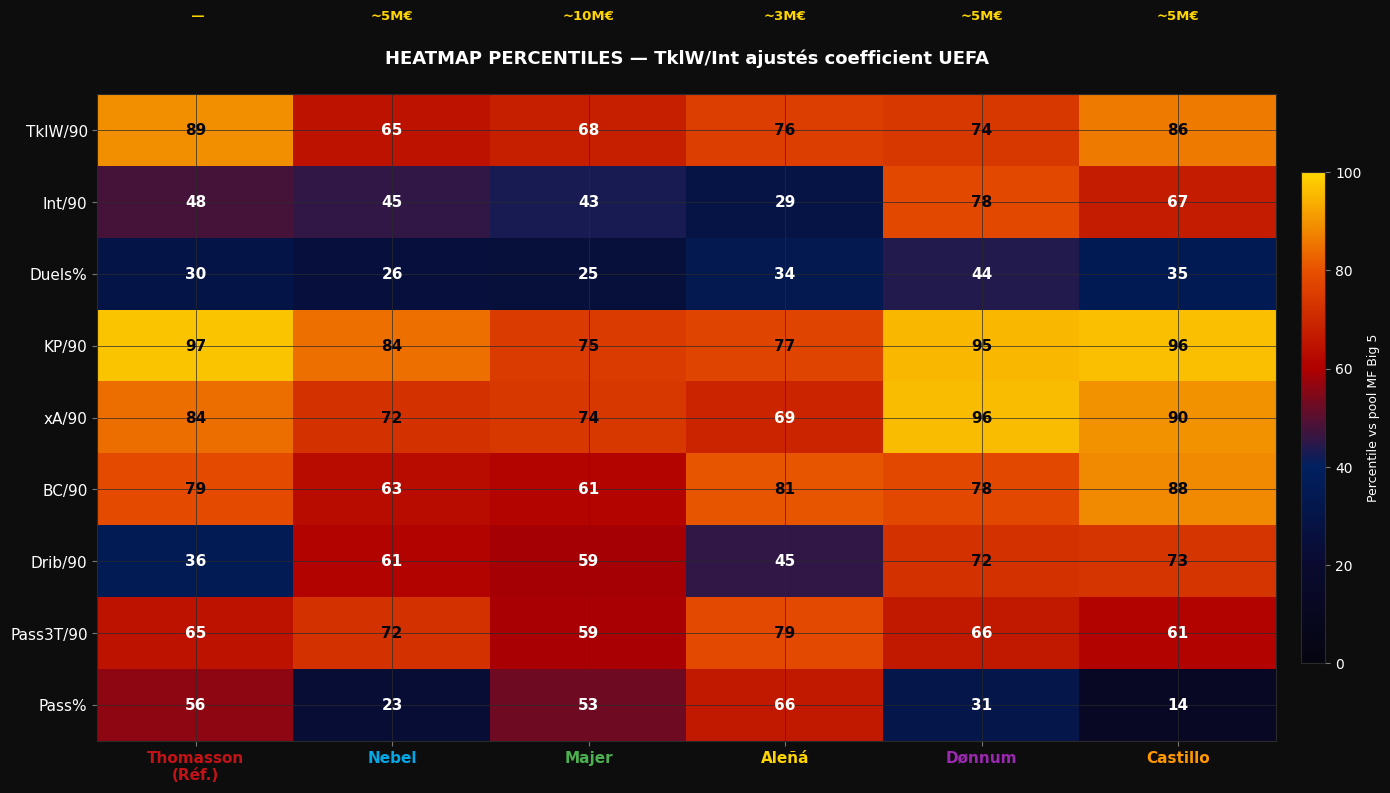

✅ fig4


In [191]:
METRICS_HM = {
    'TklW/90'   : 'TklW_p90',
    'Int/90'    : 'interceptions_p90',
    'Duels%'    : 'groundDuelsWonPercentage',
    'KP/90'     : 'keyPasses_p90',
    'xA/90'     : 'expectedAssists_p90',
    'BC/90'     : 'bigChancesCreated_p90',
    'Drib/90'   : 'successfulDribbles_p90',
    'Pass3T/90' : 'accurateFinalThirdPasses_p90',
    'Pass%'     : 'accuratePassesPercentage',
}
SL_BUDG = ['~5M€','~10M€','~3M€','~5M€','~5M€']

players=[T.to_frame().T.copy()]; lbls=['Thomasson\n(Réf.)']; budgets=['  — ']; cols_lbl=[R]
for kw,disp,col,bud in zip(SL_KW,SL_DISP,SL_COLS_PLOTLY,SL_BUDG):
    r=MF_bud[MF_bud['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): r=MF_min[MF_min['player__name'].str.contains(kw,na=False,case=False)]
    if len(r): players.append(r.iloc[0:1].copy()); lbls.append(disp.split()[-1]); budgets.append(bud); cols_lbl.append(col)

ap  = pd.concat(players,ignore_index=True)
mc  = list(METRICS_HM.values()); ml=list(METRICS_HM.keys())
mat = np.zeros((len(mc),len(ap)))
for j in range(len(ap)):
    for i,col in enumerate(mc):
        val = float(ap.iloc[j][col]) if col in ap.columns and not pd.isna(ap.iloc[j][col]) else 0.0
        ref = MF[col].dropna() if col in MF.columns else pd.Series([0])
        mat[i,j] = (ref<val).mean()*100

fig,ax=plt.subplots(figsize=(14,8),facecolor=F)
cmap_hm=mcolors.LinearSegmentedColormap.from_list('lens',['#050510','#0A0A30','#002060','#B00000','#E85000','#FFD700'])
im=ax.imshow(mat,cmap=cmap_hm,aspect='auto',vmin=0,vmax=100)
ax.set_xticks(range(len(lbls))); ax.set_xticklabels(lbls,fontsize=11,fontweight='bold')
for tick,c in zip(ax.get_xticklabels(),cols_lbl): tick.set_color(c)
ax.set_yticks(range(len(ml))); ax.set_yticklabels(ml,fontsize=11,color=W)
for i in range(len(ml)):
    for j in range(len(ap)):
        ctxt='#050510' if mat[i,j]>70 else W
        ax.text(j,i,f'{mat[i,j]:.0f}',ha='center',va='center',fontsize=11,color=ctxt,fontweight='bold')
for j,b in enumerate(budgets):
    ax.text(j,-1.5,b,ha='center',va='bottom',fontsize=9.5,color=OR,fontweight='bold')
cbar=plt.colorbar(im,ax=ax,fraction=0.02,pad=0.02)
cbar.set_label('Percentile vs pool MF Big 5',color=W,fontsize=9)
plt.setp(cbar.ax.yaxis.get_ticklabels(),color=W)
ax.set_title('HEATMAP PERCENTILES — TklW/Int ajustés coefficient UEFA',color=W,fontsize=13,fontweight='bold',pad=22)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig4_heatmap.png',dpi=150,bbox_inches='tight',facecolor=F)
plt.show(); print("✅ fig4")

### Fig 5 — Bar Chart Interactif — Scores comparés (Plotly) 🆕

In [192]:
# Données pour bar chart
names = ['Thomasson\n(Réf.)'] + [p.split()[-1] for p in SL_DISP]
cols_bar = [R, B, VT, OR, PU, OG]
press_vals = [T['s_press_n']]
crea_vals  = [T['s_crea_n']]
trans_vals = [T['s_trans_n']]

for kw in SL_KW:
    r = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if len(r):
        r = r.iloc[0]
        press_vals.append(r['s_press_n'])
        crea_vals.append(r['s_crea_n'])
        trans_vals.append(r['s_trans_n'])

fig_bar = go.Figure()
for vals, label, color, pattern in [
    (press_vals, 'Pressing (×coef UEFA)', R, ''),
    (crea_vals,  'Création',              OR, '/'),
    (trans_vals, 'Transition',            CDF, 'x'),
]:
    fig_bar.add_trace(go.Bar(
        name=label, x=names, y=vals,
        marker=dict(color=color, opacity=0.85, pattern_shape=pattern),
        hovertemplate='<b>%{x}</b><br>' + label + ': <b>%{y:.1f}</b>/100<extra></extra>'
    ))

fig_bar.update_layout(
    **PLOTLY_THEME,
    barmode='group',
    title=dict(text='<b>SCORES COMPOSITES — Shortlist vs Thomasson</b><br><sup>Pressing / Création / Transition · 0–100</sup>',
               font=dict(color=W, size=13), x=0.5),
    yaxis_title='Score (0–100)',
    legend=dict(font=dict(color=W, size=10), bgcolor='rgba(0,0,0,0.5)'),
    height=450,
)
fig_bar.show()
fig_bar.write_html(f'{FIGDIR}/fig5_bar_scores.html')
print("✅ fig5 Plotly bar")

✅ fig5 Plotly bar


### Fig 6 — Radars comparatifs Top 3 vs Thomasson (Matplotlib)

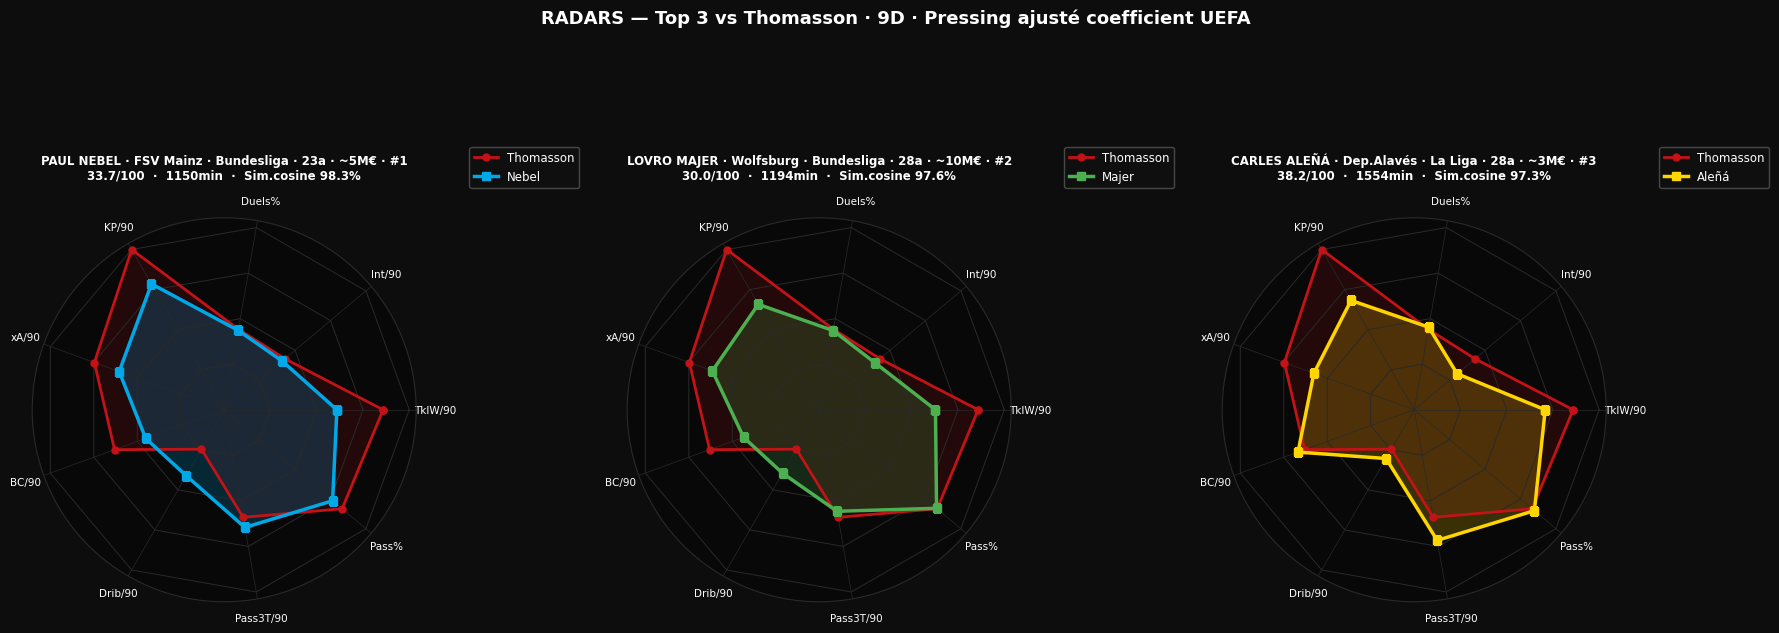

✅ fig6


In [193]:
COMP3 = [
    ('Nebel',   B,  'PAUL NEBEL · FSV Mainz · Bundesliga · 23a · ~5M€ · #1'),
    ('Majer',   VT, 'LOVRO MAJER · Wolfsburg · Bundesliga · 28a · ~10M€ · #2'),
    ('Aleñá',   OR, 'CARLES ALEÑÁ · Dep.Alavés · La Liga · 28a · ~3M€ · #3'),
]
fig,axes=plt.subplots(1,3,figsize=(18,7),subplot_kw=dict(polar=True),facecolor=F)
fig.patch.set_facecolor(F)
for ax,(kw,col,title) in zip(axes,COMP3):
    r=MF_bud[MF_bud['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): r=MF_min[MF_min['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): ax.axis('off'); continue
    r=r.iloc[0]; cv=radar_vals(r)+[radar_vals(r)[0]]
    ax.set_facecolor('#080808')
    for ring in [0.25,0.5,0.75,1.0]: ax.plot(angles,[ring]*len(angles),'-',color=G2,lw=0.7)
    ax.fill(angles,tv,color=R,alpha=0.15)
    ax.plot(angles,tv,'o-',color=R,lw=2.0,ms=5,label='Thomasson')
    ax.fill(angles,cv,color=col,alpha=0.20)
    ax.plot(angles,cv,'s-',color=col,lw=2.5,ms=6,label=r['player__name'].split()[-1])
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(RADAR_LABELS,size=7.5,color=W)
    ax.set_yticks([]); ax.spines['polar'].set_color(G2)
    sim=r['knn_sim']
    ax.legend(loc='upper right',bbox_to_anchor=(1.44,1.20),fontsize=8.5,framealpha=0.3,labelcolor=W)
    ax.set_title(f"{title}\n{r['s_final_n']:.1f}/100  ·  {r['minutesPlayed']:.0f}min  ·  Sim.cosine {sim:.1f}%",
                 color=W,fontsize=8.5,fontweight='bold',pad=28)
fig.suptitle('RADARS — Top 3 vs Thomasson · 9D · Pressing ajusté coefficient UEFA',color=W,fontsize=13,fontweight='bold',y=1.04)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig6_radars_top3.png',dpi=150,bbox_inches='tight',facecolor=F)
plt.show(); print("✅ fig6")

### Fig 7 — Podium final interactif (Plotly) 🆕

In [194]:
PODIUM_DATA = []
for kw, disp, col in zip(SL_KW, SL_DISP, SL_COLS_PLOTLY):
    r = MF_bud[MF_bud['player__name'].str.contains(kw, na=False, case=False)]
    if not len(r): r = MF_min[MF_min['player__name'].str.contains(kw, na=False, case=False)]
    if len(r):
        r = r.iloc[0]
        PODIUM_DATA.append(dict(
            name=r['player__name'], disp=disp, col=col,
            sim=r['knn_sim'], score=r['s_final_n'],
            press=r['s_press_n'], crea=r['s_crea_n'], trans=r['s_trans_n'],
            val=r['valeur_m'], age=int(r['player_age']),
            min=int(r['minutesPlayed']), coef=r.get('league_coef',1.0)
        ))

fig_pod = make_subplots(
    rows=2, cols=5,
    subplot_titles=[f"#{i+1} {p['name'].split()[-1]}" for i,p in enumerate(PODIUM_DATA)],
    vertical_spacing=0.12,
    horizontal_spacing=0.04,
    specs=[
        [{"type": "xy"}]*5,
        [{"type": "domain"}]*5   # 👈 IMPORTANT
    ]
)

metrics_pod = ['Pressing', 'Création', 'Transition']
colors_pod  = [R, OR, VT]

for j,p in enumerate(PODIUM_DATA):
    col_idx = j+1
    vals = [p['press'], p['crea'], p['trans']]
    
    # Bar scores
    fig_pod.add_trace(go.Bar(
        x=metrics_pod, y=vals,
        marker_color=colors_pod, showlegend=False, name=p['name'],
        hovertemplate='<b>'+p['name']+'</b><br>%{x}: <b>%{y:.1f}</b>/100<extra></extra>'
    ), row=1, col=col_idx)
    
    # Similarity gauge (donut)
    fig_pod.add_trace(go.Pie(
        values=[p['sim'], 100-p['sim']],
        hole=0.7,
        marker_colors=[p['col'], '#1a1a1a'],
        showlegend=False, textinfo='none',
        hovertemplate=f'<b>{p["name"]}</b><br>Similarité: <b>{p["sim"]:.1f}%</b><extra></extra>'
    ), row=2, col=col_idx)

# Annotations pour les donuts
for j,p in enumerate(PODIUM_DATA):
    fig_pod.add_annotation(
        text=f"<b>{p['sim']:.0f}%</b><br><span style='font-size:9px;color:#888'>sim</span>",
        x=(j*0.225)+0.09, y=0.17, xref='paper', yref='paper',
        showarrow=False, font=dict(color=p['col'], size=12)
    )

fig_pod.update_layout(
    **PLOTLY_THEME,
    title=dict(
        text='<b>PODIUM FINAL — Thomasson Engine v12 · RC Lens 2025/26</b><br><sup>k-NN Cosine Similarity · Coef. UEFA · Budget ≤15M€ · ≤29 ans · RC Lens exclu · Interactif</sup>',
        font=dict(color=W, size=14), x=0.5
    ),
    height=650,
)
fig_pod.show()
fig_pod.write_html(f'{FIGDIR}/fig7_podium_interactif.html')
print("✅ fig7 Plotly podium")

✅ fig7 Plotly podium


### Fig 8 — Budget RC Lens (Matplotlib)

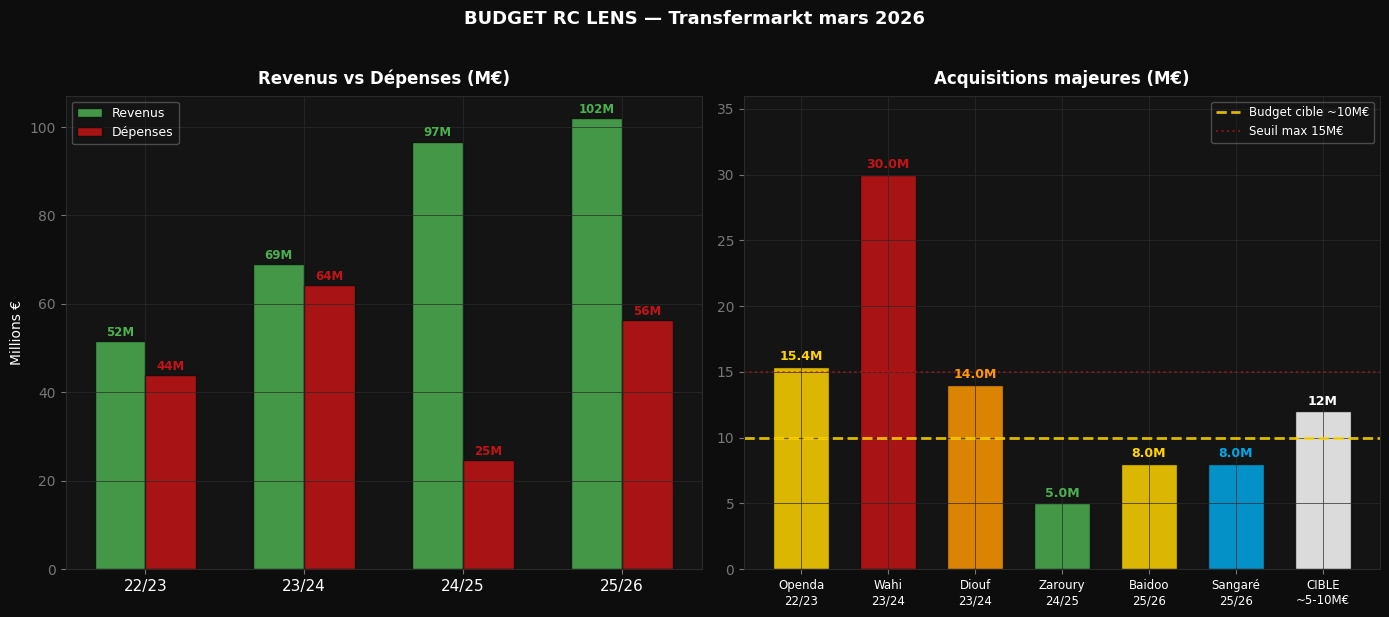

✅ fig8


In [195]:
fig,axes=plt.subplots(1,2,figsize=(14,6),facecolor=F)
ax=axes[0]
saisons=['22/23','23/24','24/25','25/26']; rev=[51.6,69.0,96.7,102.0]; dep=[43.9,64.3,24.7,56.4]
x,w=np.arange(4),0.32
b1=ax.bar(x-w/2,rev,w,label='Revenus',color=VT,alpha=0.85,edgecolor=F)
b2=ax.bar(x+w/2,dep,w,label='Dépenses',color=R,alpha=0.85,edgecolor=F)
for bar,val,c in zip(list(b1)+list(b2),rev+dep,[VT]*4+[R]*4):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1.2,f'{val:.0f}M',ha='center',fontsize=8.5,color=c,fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(saisons,color=W,fontsize=11)
ax.set_ylabel('Millions €',color=W); ax.set_title('Revenus vs Dépenses (M€)',color=W,fontweight='bold',pad=8)
ax.legend(fontsize=9,framealpha=0.3,labelcolor=W)

ax2=axes[1]
ACQS=[('Openda\n22/23',15.4,OR),('Wahi\n23/24',30.0,R),('Diouf\n23/24',14.0,OG),
      ('Zaroury\n24/25',5.0,VT),('Baidoo\n25/26',8.0,OR),('Sangaré\n25/26',8.0,B),
      ('CIBLE\n~5-10M€',12,W)]
bars=ax2.bar(range(len(ACQS)),[v for _,v,_ in ACQS],color=[c for _,_,c in ACQS],alpha=0.85,edgecolor=F,width=0.65)
for bar,(_,val,col) in zip(bars,ACQS):
    ax2.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,f'{val}M',ha='center',fontsize=9,color=col,fontweight='bold')
ax2.axhline(10,color=OR,ls='--',lw=2.0,alpha=0.85,label='Budget cible ~10M€')
ax2.axhline(15,color=R,ls=':',lw=1.5,alpha=0.60,label='Seuil max 15M€')
ax2.set_xticks(range(len(ACQS))); ax2.set_xticklabels([n for n,_,_ in ACQS],fontsize=8.5,color=W)
ax2.set_ylim(0,36); ax2.legend(fontsize=8.5,framealpha=0.3,labelcolor=W)
ax2.set_title('Acquisitions majeures (M€)',color=W,fontweight='bold',pad=8)
fig.suptitle('BUDGET RC LENS — Transfermarkt mars 2026',color=W,fontsize=13,fontweight='bold',y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/fig8_budget.png',dpi=150,bbox_inches='tight',facecolor=F)
plt.show(); print("✅ fig8")

## 8. Conclusion — Verdict Final

In [196]:
print("=" * 80)
print("THOMASSON ENGINE v12 — VERDICT FINAL")
print(f"Auteur : Zakaria  |  {len(MF)} MF analysés  |  k-NN + Coef. UEFA  |  5 candidats")
print("=" * 80)
print()
print("CORRECTIONS v12 vs v11 :")
print("  [FIX] k-NN : n_neighbors=200 au lieu de 31 — tous les joueurs scorés")
print("  [+]  Visualisations Plotly interactives (radar, scatter, bar, podium)")
print()
print("SHORTLIST v12 :")
print("-" * 80)

VERDICT = [
    ('Paul Nebel',          'FSV Mainz · Bundesliga', '23a','15M€',
     'Clone pressing+création · 23 ans · profil de revente élevé · coef×1.08'),
    ('Lovro Majer',         'Wolfsburg · Bundesliga',  '28a','10M€',
     'Exp. internationale · technique solide · bon passeur sous pression · coef×1.08'),
    ('Carles Aleñá',        'Dep.Alavés · La Liga',    '28a','3.5M€',
     'Meilleur rapport qualité/prix · décote Alavés · coef×1.20 → tacle valorisé'),
    ('Aron Dønnum',         'Toulouse · Ligue 1',      '27a','5M€',
     'Connaît la L1 · adaptation zéro · Moneyball · meilleur rating (7.35) de la SL'),
    ('Romain Del Castillo', 'Brestois · Ligue 1',      '29a','7M€',
     'Maturité immédiate · meilleure création de la SL · joueur de système'),
]
for i,(name,club,age,bud,note) in enumerate(VERDICT,1):
    kw=name.split()[-1]
    r=MF_bud[MF_bud['player__name'].str.contains(kw,na=False,case=False)]
    if not len(r): r=MF_min[MF_min['player__name'].str.contains(kw,na=False,case=False)]
    if len(r):
        r=r.iloc[0]
        print(f"[#{i}] {r['player__name']} · {club} · {age} · {bud}")
        print(f"  Sim.cosine {r['knn_sim']:.1f}%  Score {r['s_final_n']:.1f}/100  "
              f"Press:{r['s_press_n']:.0f}  Crea:{r['s_crea_n']:.0f}  Trans:{r['s_trans_n']:.0f}  "
              f"Coef ligue ×{r.get('league_coef',1.0):.2f}")
        print(f"  {r['minutesPlayed']:.0f}min · TklW {r.get('TklW_p90',0):.2f}/90 · "
              f"KP {r.get('keyPasses_p90',0):.2f}/90 · xA {r.get('expectedAssists_p90',0):.3f}/90"
              f" · Rating {r.get('rating',0):.2f}")
        print(f"  → {note}"); print()

THOMASSON ENGINE v12 — VERDICT FINAL
Auteur : Zakaria  |  642 MF analysés  |  k-NN + Coef. UEFA  |  5 candidats

CORRECTIONS v12 vs v11 :
  [FIX] k-NN : n_neighbors=200 au lieu de 31 — tous les joueurs scorés
  [+]  Visualisations Plotly interactives (radar, scatter, bar, podium)

SHORTLIST v12 :
--------------------------------------------------------------------------------
[#1] Paul Nebel · FSV Mainz · Bundesliga · 23a · 15M€
  Sim.cosine 98.3%  Score 33.7/100  Press:30  Crea:44  Trans:28  Coef ligue ×1.08
  1150min · TklW 1.10/90 · KP 1.80/90 · xA 0.153/90 · Rating 6.35
  → Clone pressing+création · 23 ans · profil de revente élevé · coef×1.08

[#2] Lovro Majer · Wolfsburg · Bundesliga · 28a · 10M€
  Sim.cosine 97.6%  Score 30.0/100  Press:32  Crea:41  Trans:23  Coef ligue ×1.08
  1194min · TklW 1.13/90 · KP 1.51/90 · xA 0.156/90 · Rating 6.66
  → Exp. internationale · technique solide · bon passeur sous pression · coef×1.08

[#3] Carles Aleñá · Dep.Alavés · La Liga · 28a · 3.5M€
 